In [ ]:
# Chapter 4 Examples, Writing with Big Data, and Suggested Reports

In [1]:
# Mount theh google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Example 4-1  (Chapter 4.1 of your textbook)

### Bar Chart (frequency distribution for a ***categorial*** variable)

*    A frequency distribution for a categorial variable groups the observations into categories and records the number of observations taht fall into each category.

*   A relative frequency distribution records the proportion of observations in each category.

* A percent frequency distribution records the percentage of observations in each category.






In [3]:
# Example 4.1
# Import the Transactions data file into a DataFrame and label it myData.  Enter:

import pandas as pd
myData = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/2510/2510-MH/MH-Ch4/jaggia_ba_2025_ch04_data.xlsx', sheet_name = 'Transactions')
myData.head(n=10)

#Satisfaction 1: very dissatisifed 5: very satisfied
#Repeat: whether the customer is a repeat custoer (Repeat = Yes or NO).







,Customer,Purchase,Income,Satisfaction,Repeat,Sex
0,1,241,53,1,No,Male
1,2,843,94,3,Yes,Male
2,3,719,64,5,Yes,Male
3,4,582,60,1,Yes,Male
4,5,345,47,4,No,Male
5,6,452,67,3,Yes,Male
6,7,553,162,5,Yes,Female
7,8,475,76,4,No,Male
8,9,247,42,5,No,Male
9,10,408,71,3,Yes,Male


In [4]:
# frequency distributions
Repeat_Frequency = myData['Repeat'].value_counts()
print(type(Repeat_Frequency))  # --> note that Repeat_Frequency is a type series (1 d array with an index)
print(Repeat_Frequency)
Sex_Frequency = myData['Sex'].value_counts()
print(Sex_Frequency)

print("***********************************************************\n\n")

# normalize = True --> return proportions (relative frequencies) instead of raw counts
Repeat_Proportion = myData['Repeat'].value_counts(normalize = True)
print(Repeat_Proportion)
Sex_Proportion = myData['Sex'].value_counts(normalize = True)
print(Sex_Proportion)

<class 'pandas.core.series.Series'>
Repeat
Yes    140
No      60
Name: count, dtype: int64
Sex
Male      150
Female     50
Name: count, dtype: int64
***********************************************************


Repeat
Yes    0.7
No     0.3
Name: proportion, dtype: float64
Sex
Male      0.75
Female    0.25
Name: proportion, dtype: float64


In [ ]:
#Combining frequency and relative frequency distributions
print(pd.DataFrame({  #used the dictonary to combine two distributions
    'Frequency': Repeat_Frequency,
    'Relative frequency': Repeat_Proportion}))

print("*****************************************\n")

print(pd.DataFrame({
    'Frequency': Sex_Frequency,
    'Relative frequency': Sex_Proportion}))


        Frequency  Relative frequency
Repeat                               
Yes           140                 0.7
No             60                 0.3
*****************************************

        Frequency  Relative frequency
Sex                                  
Male          150                0.75
Female         50                0.25


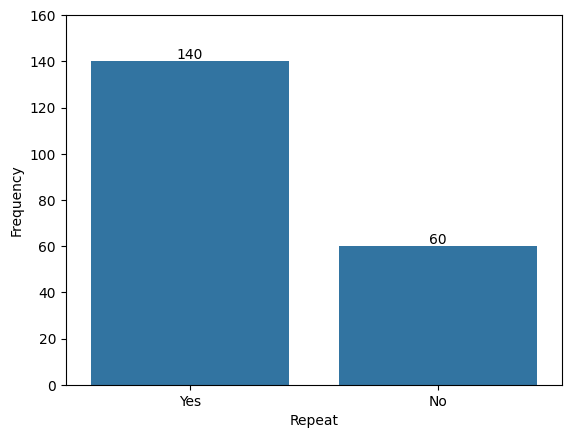

In [ ]:
# Constructing bar charts for Repeat
import seaborn as sns

ax = sns.barplot(x = Repeat_Frequency.index,
                 y = Repeat_Frequency.values)

ax.set(ylim = (0, 160),
       ylabel = 'Frequency')

ax.bar_label(ax.containers[0]);  # add labels in the graph (140, 60, for example)


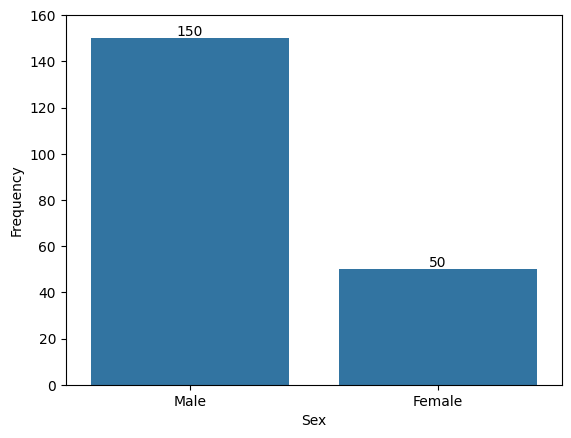

In [ ]:
#Installing matplotlib to show multiple plots
#import matplotlib.pyplot as plt
#plt.show()

ax = sns.barplot(x = Sex_Frequency.index,
                 y = Sex_Frequency.values)

ax.set(ylim = (0, 160),
       ylabel = 'Frequency')

ax.bar_label(ax.containers[0]);
#plt.show()

## Example 4.2 (Chapter 4.1 of your textbook) - Frequency distribution for a numerical variable


*   For a numerical variable, a frequency distribution groups the observations into intervals and records the number of observations in each interval.
*   A relative frequency distribution records the proportion of oservation in each internval.  


### A historgram is a series of retangles where the with and height of each rectangle represent the interval width and frequency (or relative frequence) of the respective interval.

In [5]:
#Example 4.2
# Import the Transactions data file a DataFrame and label it myData

import pandas as pd
myData = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/2510/2510-MH/MH-Ch4/jaggia_ba_2025_ch04_data.xlsx', sheet_name = 'Transactions')
myData

#myData['Income'].min()




,Customer,Purchase,Income,Satisfaction,Repeat,Sex
0,1,241,53,1,No,Male
1,2,843,94,3,Yes,Male
2,3,719,64,5,Yes,Male
3,4,582,60,1,Yes,Male
4,5,345,47,4,No,Male
...,...,...,...,...,...,...
195,196,921,82,4,Yes,Female
196,197,200,49,4,No,Male
197,198,514,50,3,Yes,Female
198,199,586,52,2,Yes,Female


In [8]:
# Constructing frequency distribution
import numpy as np
intervals = np.linspace(start = 0, stop = 250, num = 6)
print("intervals:  ", intervals)
# num =6 --> 6 evenly spaced numbers from 0 to 250 inclusive. -->0, 50, 100, 150, 200, 250
#        --> 6 edges define 5 equal-width bins
#        --> (0, 50], (50, 100], (100, 150], (150, 200], (200, 250]  --> 5 bins



#pd.cut(....):  turns your numerical column into categorial categorial bins
#.value_counts(...): then counts how many rows fall in each bin.

Frequency = pd.cut(myData.Income, bins = np.linspace(0, 250, 6)).value_counts(sort = False)
# bins = 6 edges define 5 equals bins of 50

Frequency


intervals:   [  0.  50. 100. 150. 200. 250.]


,count
Income,
"(0.0, 50.0]",40
"(50.0, 100.0]",132
"(100.0, 150.0]",18
"(150.0, 200.0]",6
"(200.0, 250.0]",4


In [ ]:
# Constructing relative frequency distribution
Relative_Frequency = pd.cut(myData.Income, bins = np.linspace(0, 250, 6)).value_counts(sort = False, normalize = True)

Relative_Frequency





,proportion
Income,
"(0.0, 50.0]",0.20
"(50.0, 100.0]",0.66
"(100.0, 150.0]",0.09
"(150.0, 200.0]",0.03
"(200.0, 250.0]",0.02


In [ ]:
# Combining frequency and relative frequency distributions using Pandas DataFrame
print(pd.DataFrame({
    'Frequency': Frequency,
    'Relative frequency': Relative_Frequency}))


                Frequency  Relative frequency
Income                                       
(0.0, 50.0]            40                0.20
(50.0, 100.0]         132                0.66
(100.0, 150.0]         18                0.09
(150.0, 200.0]          6                0.03
(200.0, 250.0]          4                0.02


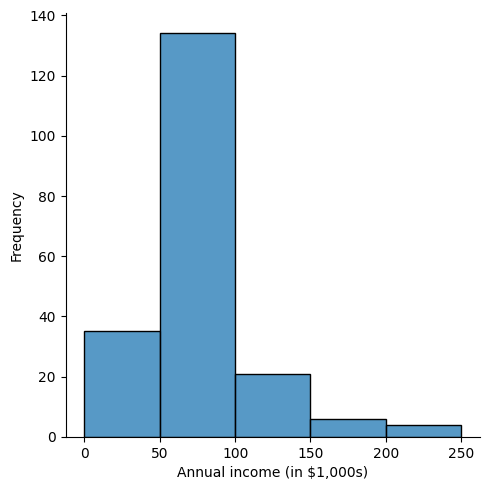

In [9]:
# Construct histogram
import seaborn as sns
ax = sns.displot(myData.Income,
                 bins = np.linspace(0, 250, 6))

ax.set(xticks = intervals,
       xlabel = 'Annual income (in $1,000s)',
       ylabel = 'Frequency')

# The above diagram is positivly skwewed